Plot the LPP amplitudes for items of a given category, separated by whether they were later recalled or not.

In [1]:
import os
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
import matplotlib.pyplot as plt
from jaxcmr.analyses.cat_lpp_by_recall import plot_cat_lpp_by_recall

In [2]:
data_name = "TalmiEEG"
data_query = "data['subject'] > 0"
category_field = "condition"
contrast_name = "Negative Items"
lpp_field = "EarlyLPP"
category_value = 1
labels = ["Recalled", "Unrecalled"]
color_cycle = None
ylim = None
output_path = "projects/TalmiEEG/delete_this.png"
exclude_ci = False

In [3]:
# Parameters
data_name = "TalmiEEG"
data_query = "data['subject'] > 0"
category_field = "condition"
labels = ["Recalled", "Unrecalled"]
ylim = [-0.6, 2.2]
output_path = "projects/TalmiEEG/results/figures/analyses/cat_lpp_by_recall_LateLPP_Negative.png"
category_value = 1
contrast_name = "Negative"
lpp_field = "LateLPP"
color_cycle = ["#1f77b4", "#ff7f0e"]


In [4]:
# data_name = "TalmiEEG"
# data_query = "data['subject'] > 0"
# category_field = "condition"
# contrast_name = "Condition x Recall"
# lpp_field = "EarlyLPP"
# category_value = [1, 2, 3, 4]
# labels = ["Unrecalled Negative", "Recalled Negative", "Unrecalled Neutral", "Recalled Neutral"]
# color_cycle = None
# ylim = None
# output_path = "projects/TalmiEEG/results/figures/cat_lpp_by_recall.png"
# exclude_ci = True

In [5]:
project_root = find_project_root()
data_path = os.path.join(project_root, "data", f"{data_name}.h5")
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)

if exclude_ci:
    data["subject"] = (data['subject'] * 0) + 1

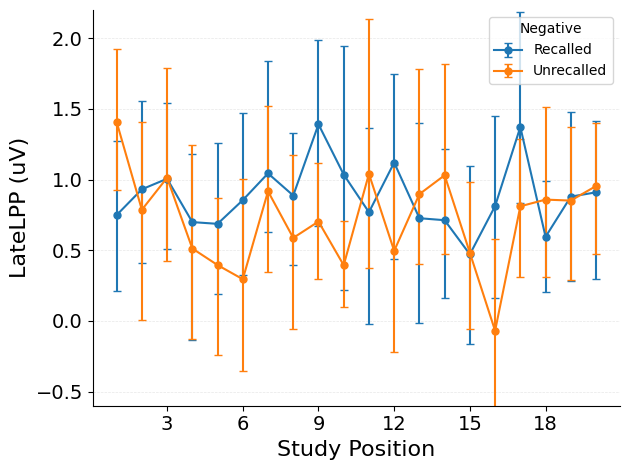

In [6]:
axis = plot_cat_lpp_by_recall(
    datasets=[data],
    trial_masks=trial_mask,
    category_field=category_field,
    category_value=category_value,
    lpp_field=lpp_field,
    color_cycle=color_cycle,
    contrast_name=contrast_name,
    labels=labels,
)
axis.set_ylim(ylim)
plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight", dpi=600)